
**Snapshots used:** 99 (z=0), 51 (z≈0.95), 33 (z≈2), 17 (z≈5).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from scipy.sparse.linalg import eigsh
import pycorr
from pycorr import TwoPointCorrelationFunction, BoxSubsampler


SNAPS = [17, 33, 51, 99]
REDSHIFTS = {99: 0.0, 51: 0.95, 33: 2.0, 17: 5.0}
H = 0.6774  # TNG cosmology

## Load Embeddings, Progenitors, and Properties

In [2]:
data99 = np.load('snapshot99_embedding_r2_all.npz')
positions_z0 = data99['positions']   # shape (N, 3): [x, y, z] per galaxy
print(positions_z0.shape)

(27691, 3)


In [3]:
data99.keys()

KeysView(NpzFile 'snapshot99_embedding_r2_all.npz' with keys: embedding, original_index, sorted_neighbors, positions, snapshot...)

In [4]:
data99['embedding'].shape

(27691, 10)

In [5]:
boxsize = 75.0
edges = np.logspace(np.log10(0.5), np.log10(20.0), 25)        # s bin edges in Mpc/h

# all z=0 positions, row-aligned with X[99]
positions_z0 = data99['positions']   # (N, 3) Mpc/h

# top third of embedding Dim 1
dim1   = data99['embedding'][:, 0]
thresh = np.percentile(dim1, 100 * 1/5) 
top_mask = dim1 <= thresh
print(f"all: {len(positions_z0)},  top third of Dim 1: {top_mask.sum()}")

pos_all = positions_z0
pos_top = positions_z0[top_mask]

result = TwoPointCorrelationFunction(
    's', edges,
    data_positions1=pos_all.T,              # all galaxies
    data_positions2=pos_top.T,              # quanitle
    los='z',
    boxsize=boxsize,
)

s, xi = result(return_sep=True)
for r, x in zip(s, xi):
    print(f"s = {r:6.2f} Mpc/h   xi = {x:+.4f}")


all: 27691,  top third of Dim 1: 5539
s =   0.54 Mpc/h   xi = +301.9370
s =   0.63 Mpc/h   xi = +247.9560
s =   0.74 Mpc/h   xi = +186.5585
s =   0.86 Mpc/h   xi = +141.8303
s =   1.00 Mpc/h   xi = +104.9328
s =   1.17 Mpc/h   xi = +74.0586
s =   1.36 Mpc/h   xi = +50.6756
s =   1.59 Mpc/h   xi = +34.7039
s =   1.85 Mpc/h   xi = +23.0525
s =   2.16 Mpc/h   xi = +15.3738
s =   2.52 Mpc/h   xi = +10.4970
s =   2.94 Mpc/h   xi = +7.3624
s =   3.43 Mpc/h   xi = +5.5306
s =   3.99 Mpc/h   xi = +4.0226
s =   4.66 Mpc/h   xi = +3.0322
s =   5.43 Mpc/h   xi = +1.9605
s =   6.34 Mpc/h   xi = +1.2784
s =   7.41 Mpc/h   xi = +0.9975
s =   8.64 Mpc/h   xi = +0.7792
s =  10.05 Mpc/h   xi = +0.6262
s =  11.74 Mpc/h   xi = +0.3011
s =  13.71 Mpc/h   xi = +0.1959
s =  15.98 Mpc/h   xi = +0.1094
s =  18.66 Mpc/h   xi = +0.0793


In [6]:
top_mask

array([ True,  True,  True, ...,  True,  True,  True], shape=(27691,))

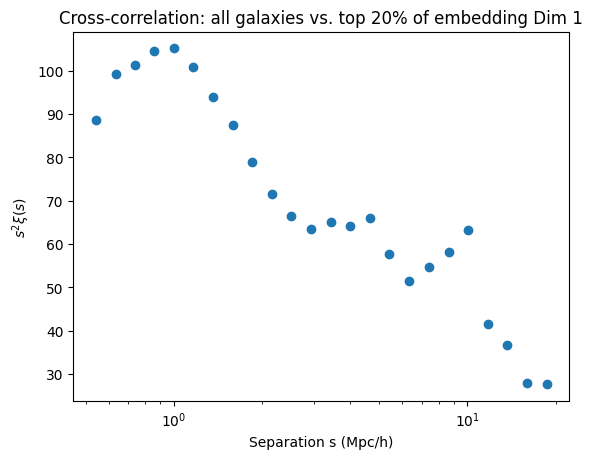

In [7]:
plt.plot(s, s**2 * xi, 'o')
plt.xlabel('Separation s (Mpc/h)')
plt.ylabel("$s^2 \\xi(s)$")
plt.title('Cross-correlation: all galaxies vs. top 20% of embedding Dim 1')
plt.xscale('log')
plt.show()

In [8]:
boxsize = 75.0
edges = np.logspace(np.log10(0.005), np.log10(20.0), 25)    # s bin edges in Mpc/h

# all z=0 positions, row-aligned with X[99]
positions_z0 = data99['positions']   # (N, 3) Mpc/h

# top third of embedding Dim 1
dim1   = data99['embedding'][:, 0]
dim2   = data99['embedding'][:, 1]
dim3   = data99['embedding'][:, 2]

thresh = np.percentile(dim1, 100 * 4/5) 
top_mask = dim1 >= thresh
print(f"all: {len(positions_z0)},  top third of Dim 1: {top_mask.sum()}")

pos_all = positions_z0
pos_top = positions_z0[top_mask]

result = TwoPointCorrelationFunction(
    's', edges,
    data_positions1=pos_all.T,              # all galaxies
    data_positions2=pos_top.T,              # quanitle
    los='z',
    boxsize=boxsize,
)

s, xi = result(return_sep=True)
for r, x in zip(s, xi):
    print(f"s = {r:6.2f} Mpc/h   xi = {x:+.4f}")

all: 27691,  top third of Dim 1: 5539
s =   0.01 Mpc/h   xi = +28861.2892
s =   0.01 Mpc/h   xi = +18421.3819
s =   0.01 Mpc/h   xi = +10160.8741
s =   0.02 Mpc/h   xi = +10294.5195
s =   0.02 Mpc/h   xi = +3330.3759
s =   0.03 Mpc/h   xi = +2118.8961
s =   0.05 Mpc/h   xi = +934.3484
s =   0.07 Mpc/h   xi = +548.4043
s =   0.10 Mpc/h   xi = +241.4432
s =   0.14 Mpc/h   xi = +126.4215
s =   0.19 Mpc/h   xi = +47.1782
s =   0.27 Mpc/h   xi = +23.1945
s =   0.38 Mpc/h   xi = +8.9371
s =   0.54 Mpc/h   xi = +3.8102
s =   0.77 Mpc/h   xi = +2.0815
s =   1.08 Mpc/h   xi = +0.6706
s =   1.52 Mpc/h   xi = -0.0793
s =   2.23 Mpc/h   xi = +0.0295
s =   3.09 Mpc/h   xi = +0.2571
s =   4.37 Mpc/h   xi = +0.2592
s =   6.15 Mpc/h   xi = +0.1652
s =   8.71 Mpc/h   xi = +0.0842
s =  12.30 Mpc/h   xi = +0.0542
s =  17.40 Mpc/h   xi = +0.0208


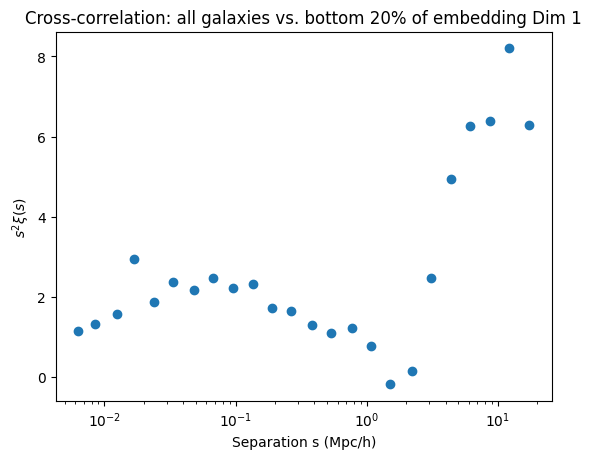

In [9]:
plt.plot(s, s**2 * xi, 'o')
plt.xlabel('Separation s (Mpc/h)')
plt.ylabel("$s^2 \\xi(s)$")
plt.title('Cross-correlation: all galaxies vs. bottom 20% of embedding Dim 1')
plt.xscale('log')
plt.show()

s =   0.01 Mpc/h   xi = +50805.8016
s =   0.01 Mpc/h   xi = +34393.6557
s =   0.01 Mpc/h   xi = +18438.8720
s =   0.02 Mpc/h   xi = +12716.2625
s =   0.02 Mpc/h   xi = +6717.7271
s =   0.03 Mpc/h   xi = +3773.4201
s =   0.05 Mpc/h   xi = +2260.3116
s =   0.07 Mpc/h   xi = +1461.9004
s =   0.10 Mpc/h   xi = +945.5654
s =   0.14 Mpc/h   xi = +596.8119
s =   0.19 Mpc/h   xi = +384.6039
s =   0.27 Mpc/h   xi = +243.4855
s =   0.38 Mpc/h   xi = +146.8303
s =   0.54 Mpc/h   xi = +84.3809
s =   0.76 Mpc/h   xi = +45.5222
s =   1.07 Mpc/h   xi = +21.8677
s =   1.52 Mpc/h   xi = +9.6966
s =   2.16 Mpc/h   xi = +4.5932
s =   3.06 Mpc/h   xi = +2.5575
s =   4.33 Mpc/h   xi = +1.4562
s =   6.12 Mpc/h   xi = +0.7253
s =   8.68 Mpc/h   xi = +0.3743
s =  12.28 Mpc/h   xi = +0.1568
s =  17.38 Mpc/h   xi = +0.0594


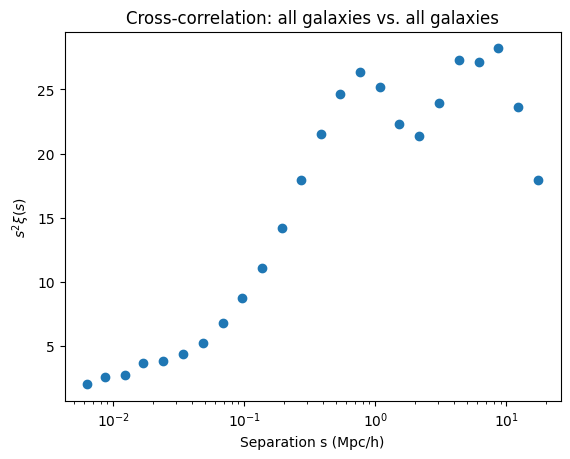

In [10]:
result = TwoPointCorrelationFunction(
    's', edges,
    data_positions1=pos_all.T,              # all galaxies           # quanitle
    los='z',
    boxsize=boxsize,
)

s, xi = result(return_sep=True)
for r, x in zip(s, xi):
    print(f"s = {r:6.2f} Mpc/h   xi = {x:+.4f}")

plt.plot(s, s**2 * xi, 'o')
plt.xlabel('Separation s (Mpc/h)')
plt.ylabel("$s^2 \\xi(s)$")
plt.title('Cross-correlation: all galaxies vs. all galaxies')
plt.xscale('log')
plt.show()

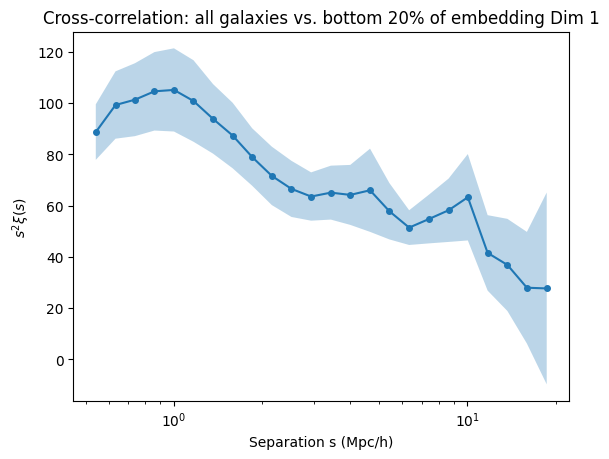

In [11]:
boxsize = 75.0
edges = np.logspace(np.log10(0.5), np.log10(20.0), 25)     # up to 20 Mpc/h

# samples: all galaxies (sample 1) and bottom 20% of Dim 1 (sample 2)
dim1 = data99['embedding'][:, 0]
mask = dim1 <= np.percentile(dim1, 20)
pos_all = positions_z0 % boxsize
pos_sub = positions_z0[mask] % boxsize

# jackknife region labels: 3x3x3 = 27 regions of 25 Mpc/h ( > s_max = 20)
subsampler = BoxSubsampler(boxsize=boxsize, boxcenter=boxsize / 2, nsamples=(3, 3, 3),
                            position_type='pos')
labels_all = subsampler.label(pos_all)     # length-N labels, aligned with pos_all rows
labels_sub = subsampler.label(pos_sub)

result = TwoPointCorrelationFunction(
    's', edges,
    data_positions1=pos_all.T, data_positions2=pos_sub.T,
    data_samples1=labels_all,  data_samples2=labels_sub,
    position_type='xyz', boxsize=boxsize, los='z',
    engine='corrfunc', nthreads=4,
)

s   = result.sep
xi  = result.corr
err = np.sqrt(np.diag(result.cov()))       # jackknife 1-sigma error

# --- shaded error region instead of error bars ---
y    = s**2 * xi
yerr = s**2 * err
plt.plot(s, y, '-o', markersize=4)
plt.fill_between(s, y - yerr, y + yerr, alpha=0.3)

plt.xlabel('Separation s (Mpc/h)')
plt.ylabel(r"$s^2 \xi(s)$")
plt.title('Cross-correlation: all galaxies vs. bottom 20% of embedding Dim 1')
plt.xscale('log')
plt.xscale('log')
plt.show()


/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_85889/833953764.py:67: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(s, y, '-o', markersize=4,  color=color, linestyle=linestyle, label=label)


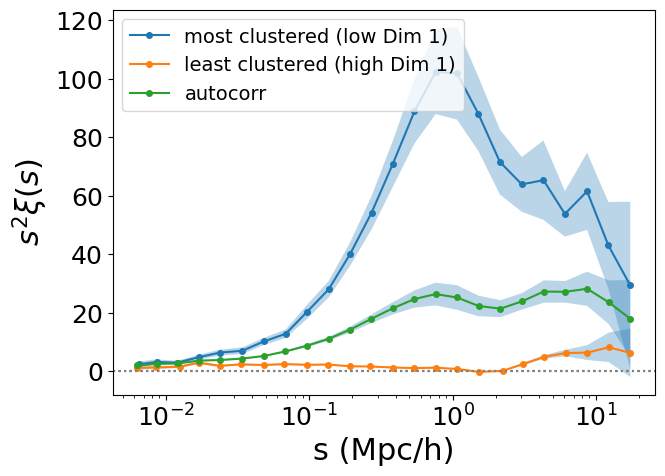

In [20]:
def plot_cross_corr(mask, positions=positions_z0, boxsize=75.0, edges=None,
                    los='z', nthreads=4, ax=None, label=None, plot_s_squared = False, color=None, linestyle='-'):
    """
    Cross-correlate the masked subpopulation against ALL galaxies and plot xi(s).

    Parameters
    ----------
    mask : bool array, shape (N,)
        Selects the subpopulation (sample 2); sample 1 is all galaxies.
    positions : (N, 3) array
        Galaxy positions in Mpc/h, row-aligned with `mask`.
    boxsize : float
        Periodic box length (Mpc/h).
    edges : array or None
        s bin edges (Mpc/h). Defaults to log-spaced 0.5–30.
    ax : matplotlib Axes or None
        If given, draw onto it (for overlays); else make a new figure.
    label : str or None
        Legend label for this curve.

    Returns
    -------
    s, xi : arrays
    """
    # --- publication formatting (matches the other figures) ---
    LABEL_FS  = 22   # axis labels
    TICK_FS   = 18   # tick labels
    LEGEND_FS = 14   # legend text

    if edges is None:
        edges = np.logspace(np.log10(0.005), np.log10(20.0), 25)

    pos_all = positions % boxsize
    pos_sub = positions[mask] % boxsize

    # jackknife region labels: 3x3x3 = 27 regions of 25 Mpc/h ( > s_max = 20)
    subsampler = BoxSubsampler(boxsize=boxsize, boxcenter=boxsize / 2, nsamples=(3, 3, 3),
                                position_type='pos')
    labels_all = subsampler.label(pos_all)     # length-N labels, aligned with pos_all rows
    labels_sub = subsampler.label(pos_sub)


    result = TwoPointCorrelationFunction(
        's', edges,
        data_positions1=pos_all,        # all galaxies
        data_positions2=pos_sub,        # masked subpopulation
        position_type='pos',              # arrays are (3, N) after .T
        los=los,
        boxsize=boxsize,
        nthreads=nthreads,
        data_samples1=labels_all,  
        data_samples2=labels_sub,
    )
    # s, xi, = result(return_sep=True)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xscale('log')
    if plot_s_squared:
        s   = result.sep
        xi  = result.corr
        err = np.sqrt(np.diag(result.cov()))       # jackknife 1-sigma error

        # --- shaded error region instead of error bars ---
        y    = s**2 * xi
        yerr = s**2 * err
        ax.plot(s, y, '-o', markersize=4,  color=color, linestyle=linestyle, label=label)
        ax.fill_between(s, y - yerr, y + yerr, alpha=0.3, color=color)
        # ax.plot(s, s**2 * xi, marker='o', markersize=4, lw=2, label=label, color=color, linestyle=linestyle)
        ax.set_ylabel(r'$s^2 \xi(s)$', fontsize=LABEL_FS)
    else:
        s   = result.sep
        xi  = result.corr
        err = np.sqrt(np.diag(result.cov())) 
        ax.plot(s, xi, marker='o', markersize=4, lw=2, label=label, color=color, linestyle=linestyle)
        ax.fill_between(s, xi - err, xi + err, alpha=0.3, color=color)

        ax.set_ylabel(r'$\xi(s)$', fontsize=LABEL_FS)

    ax.axhline(0, ls=':', color='gray')
    ax.set_xlabel('s (Mpc/h)', fontsize=LABEL_FS)
    ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
    ax.tick_params(axis='both', which='minor', labelsize=TICK_FS - 4)
    if label is not None:
        ax.legend(fontsize=LEGEND_FS)

    return s, xi



fig, ax = plt.subplots(figsize=(7, 5))

plot_cross_corr(dim1 <= np.percentile(dim1, 20), ax=ax, label='most clustered (low Dim 1)', plot_s_squared=True)
plot_cross_corr(dim1 >= np.percentile(dim1, 80), ax=ax, label='least clustered (high Dim 1)', plot_s_squared=True)
plot_cross_corr(dim1 <= np.max(dim1), ax=ax, label='autocorr', plot_s_squared=True)

plt.show()


/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_85889/833953764.py:67: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(s, y, '-o', markersize=4,  color=color, linestyle=linestyle, label=label)


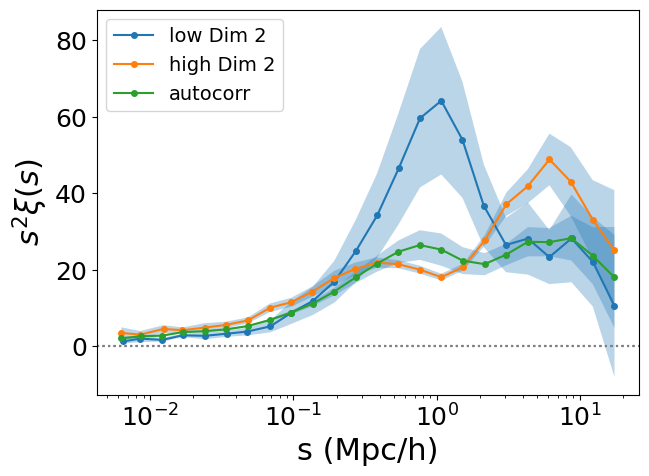

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_cross_corr(dim2 <= np.percentile(dim2, 20), ax=ax, label='low Dim 2', plot_s_squared=True)
plot_cross_corr(dim2 >= np.percentile(dim2, 80), ax=ax, label='high Dim 2', plot_s_squared=True)
plot_cross_corr(dim1 <= np.max(dim1), ax=ax, label='autocorr', plot_s_squared=True)
plt.show()

/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_85889/833953764.py:67: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(s, y, '-o', markersize=4,  color=color, linestyle=linestyle, label=label)


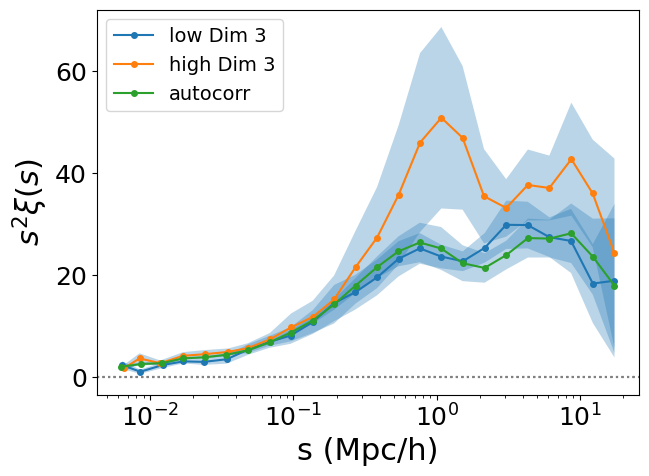

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_cross_corr(dim3 <= np.percentile(dim3, 20), ax=ax, label='low Dim 3', plot_s_squared=True)
plot_cross_corr(dim3 >= np.percentile(dim3, 80), ax=ax, label='high Dim 3', plot_s_squared=True)
plot_cross_corr(dim1 <= np.max(dim1), ax=ax, label='autocorr', plot_s_squared=True)
plt.show()

/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_85889/833953764.py:67: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(s, y, '-o', markersize=4,  color=color, linestyle=linestyle, label=label)


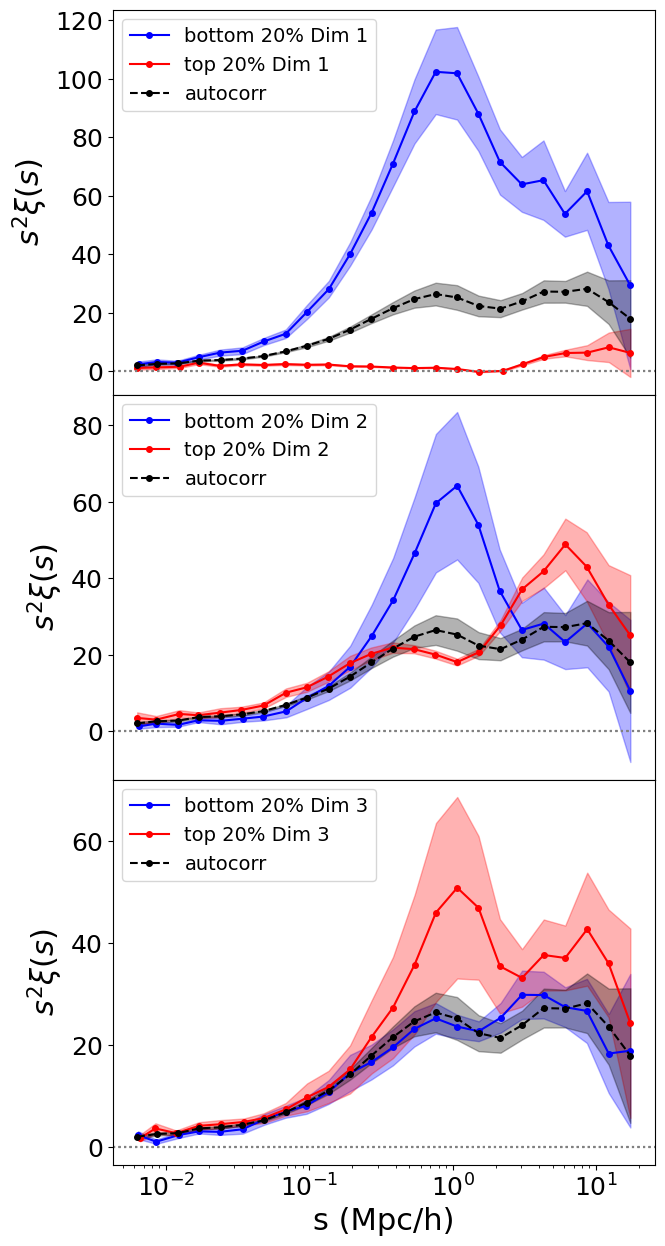

In [23]:
dims = [data99['embedding'][:, d] for d in range(3)]     # Dim 1, 2, 3 (row-aligned with positions_z0)
all_mask = np.ones(len(dims[0]), dtype=bool)             # everything -> autocorrelation

fig, axes = plt.subplots(3, 1, figsize=(7, 15), sharex=True,
                         gridspec_kw={'hspace': 0})       # <-- no vertical space
for d, ax in enumerate(axes):
    dim = dims[d]
    plot_cross_corr(dim <= np.percentile(dim, 20), ax=ax,
                    label=f'bottom 20% Dim {d+1}', plot_s_squared=True, color='blue')
    plot_cross_corr(dim >= np.percentile(dim, 80), ax=ax,
                    label=f'top 20% Dim {d+1}', plot_s_squared=True, color='red')
    plot_cross_corr(all_mask, ax=ax, label='autocorr', plot_s_squared=True,
                    color='black', linestyle='--')        # black dashed autocorr
    if d != len(axes) - 1:
        ax.set_xlabel('')            # drop redundant x-labels; keep only the bottom panel's
plt.show()


In [24]:
fig.savefig("figures/cross_correlations.pdf", bbox_inches='tight')

/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_20117/3114473274.py:62: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(s, y, '-o', markersize=4,  color=color, linestyle=linestyle, label=label)


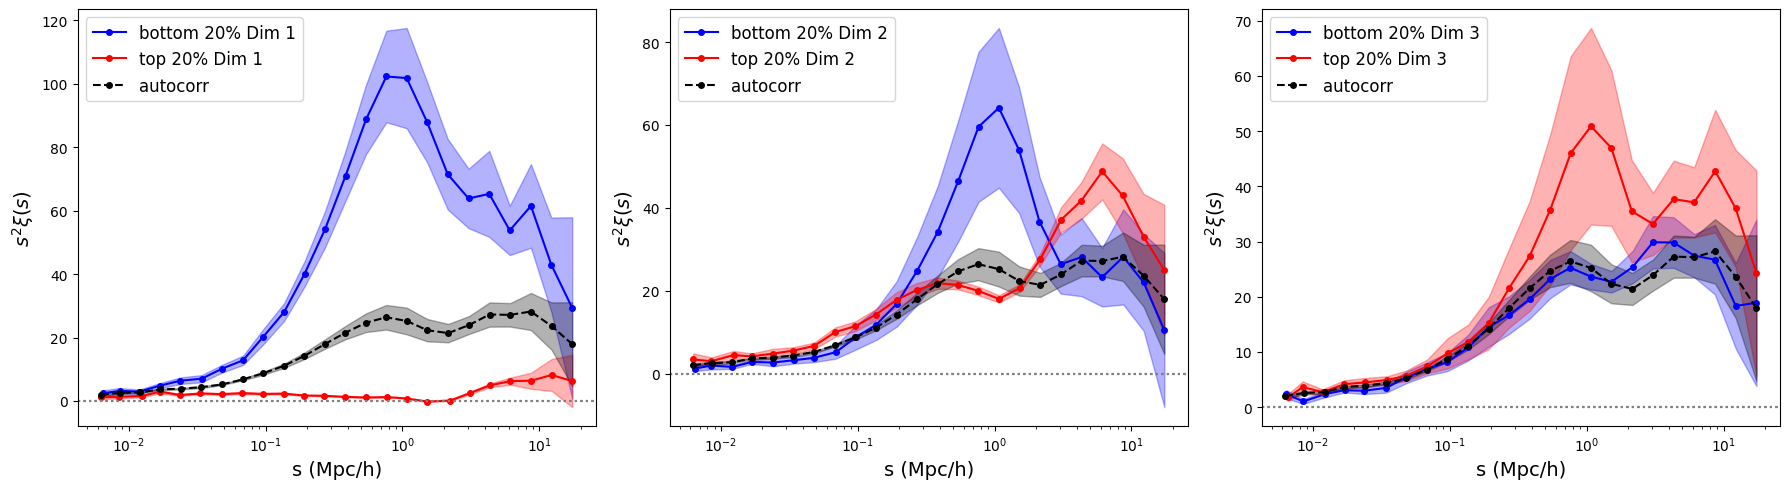

In [137]:
dims = [data99['embedding'][:, d] for d in range(3)]     # Dim 1, 2, 3 (row-aligned with positions_z0)
all_mask = np.ones(len(dims[0]), dtype=bool)             # everything -> autocorrelation

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
for d, ax in enumerate(axes):
    dim = dims[d]
    plot_cross_corr(dim <= np.percentile(dim, 20), ax=ax,
                    label=f'bottom 20% Dim {d+1}', plot_s_squared=True, color='blue')
    plot_cross_corr(dim >= np.percentile(dim, 80), ax=ax,
                    label=f'top 20% Dim {d+1}', plot_s_squared=True, color='red')
    plot_cross_corr(all_mask, ax=ax, label='autocorr', plot_s_squared=True,
                    color='black', linestyle='--')        # black dashed autocorr
plt.tight_layout()
plt.show()


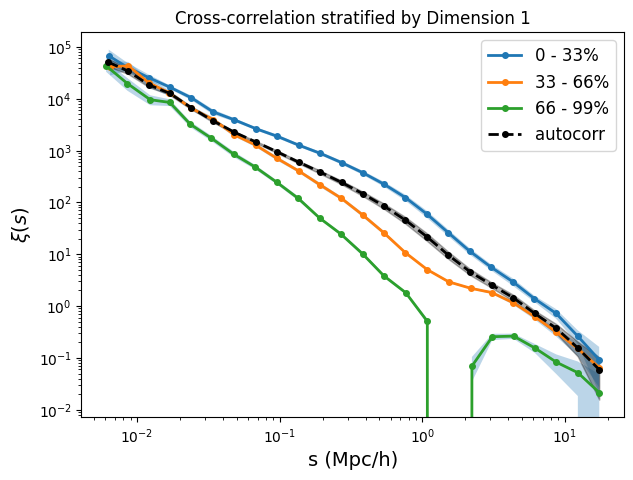

In [124]:
fig, ax = plt.subplots(figsize=(7, 5))

for i in range(3):
    mask = (dim1 <= np.percentile(dim1, 100*(1/3)*(i + 1))) & (dim1 >= np.percentile(dim1, 100*(1/3)*(i)))
    plot_cross_corr(mask, ax=ax, label=f'{33 * i} - {33 * (i+1)}%')
plot_cross_corr(dim1 <= np.max(dim1), ax=ax, label='autocorr', color='black', linestyle='--')
plt.title("Cross-correlation stratified by Dimension 1")
plt.yscale('log')
plt.show()

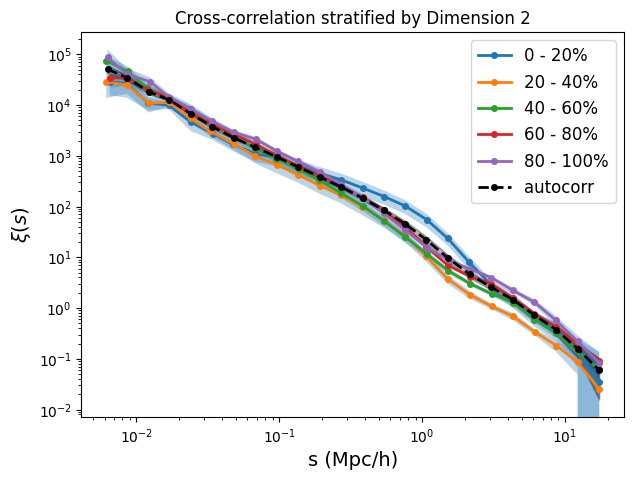

In [125]:
fig, ax = plt.subplots(figsize=(7, 5))

for i in range(5):
    mask = (dim2 <= np.percentile(dim2, 20*(i + 1))) & (dim2 >= np.percentile(dim2, 20*(i)))
    plot_cross_corr(mask, ax=ax, label=f'{20 * i} - {20 * (i+1)}%')
plot_cross_corr(dim1 <= np.max(dim1), ax=ax, label='autocorr', color='black', linestyle='--')
plt.title("Cross-correlation stratified by Dimension 2")
plt.yscale('log')
plt.show()

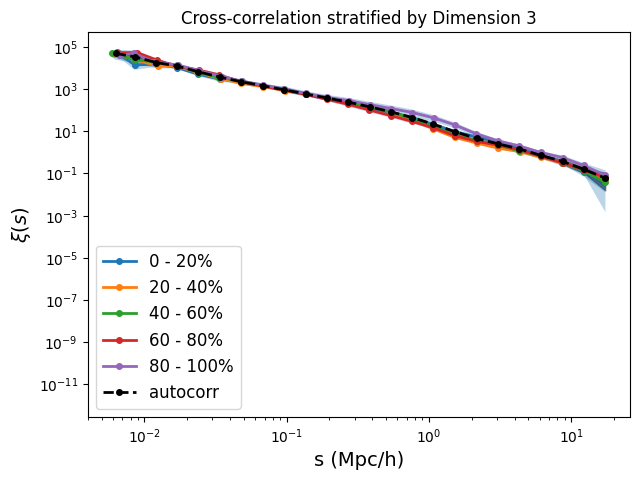

In [126]:
fig, ax = plt.subplots(figsize=(7, 5))

for i in range(5):
    mask = (dim3 <= np.percentile(dim3, 20*(i + 1))) & (dim3 >= np.percentile(dim3, 20*(i)))
    plot_cross_corr(mask, ax=ax, label=f'{20 * i} - {20 * (i+1)}%')
plot_cross_corr(dim1 <= np.max(dim1), ax=ax, label='autocorr', color='black', linestyle='--')
plt.title("Cross-correlation stratified by Dimension 3")
plt.yscale('log')
plt.show()